# Module 9 Supervised Learning II

# Objective:
    •Practice Naive Bayes algorithm based classification.
    •Identify the predictors that can be of influence by experiment.

# Questions:

    - 1.Load the kinematics dataset as measured on mobile sensors from the file “run_or_walk.csv”. 
    List out the columns in the dataset.
    
    - 2. Let the target variable ‘y’ be the activity and assign all the columns after it to ‘x’. 
    
    - 3.Using Scikit-learn fit a Gaussian Naive Bayes model and observe the accuracy.Generate a classification report using scikitlearn.
    
    - 4.Repeat the model once using only the acceleration values as predictors and then using only the gyro values as predictors. 
    Comment on the difference in accuracy between both the models.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sns

from sklearn.model_selection import train_test_split


runorwalk = pd.read_csv(r"C:\Users\prabh\PycharmProjects\Edureka_Practice\Case_Studies\Dataset\Module9\run_or_walk.csv")
runorwalk.head()

,date,time,username,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,2017-6-30,13:51:15:847724020,viktor,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,2017-6-30,13:51:16:246945023,viktor,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,2017-6-30,13:51:16:446233987,viktor,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,2017-6-30,13:51:16:646117985,viktor,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,2017-6-30,13:51:16:846738994,viktor,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922


In [8]:
##Dat wrangling
#Chcke Null in dataset, no null found
runorwalk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88588 entries, 0 to 88587
Data columns (total 11 columns):
date              88588 non-null object
time              88588 non-null object
username          88588 non-null object
wrist             88588 non-null int64
activity          88588 non-null int64
acceleration_x    88588 non-null float64
acceleration_y    88588 non-null float64
acceleration_z    88588 non-null float64
gyro_x            88588 non-null float64
gyro_y            88588 non-null float64
gyro_z            88588 non-null float64
dtypes: float64(6), int64(2), object(3)
memory usage: 7.4+ MB


In [37]:
runorwalk.date.unique()

array(['2017-6-30', '2017-7-10', '2017-7-11', '2017-7-15', '2017-7-16',
       '2017-7-17', '2017-7-1', '2017-7-2', '2017-7-4', '2017-7-6',
       '2017-7-7', '2017-7-9'], dtype=object)

In [38]:
runorwalk.username.unique()

array(['viktor'], dtype=object)

In [31]:
runorwalk.columns
#Column  list

Index(['date', 'time', 'username', 'wrist', 'activity', 'acceleration_x',
       'acceleration_y', 'acceleration_z', 'gyro_x', 'gyro_y', 'gyro_z'],
      dtype='object')

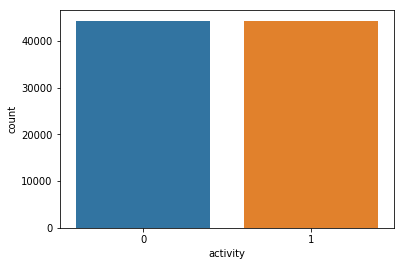

In [32]:
sns.countplot(runorwalk.activity)

In [67]:
#Split the data
# Here usernameis string and date time are object, these not req, so we will remove from X

#ANOTHER WAY
#X, Y = runorwalk.iloc[:, 5:].values,runorwalk.iloc[:, 4].values
X = runorwalk.loc[:,:]
X = X.drop(["activity","date", "time","username","wrist"], axis=1)
Y = runorwalk.loc[:,["activity"]]
Y[:5]


,activity
0,0
1,0
2,0
3,0
4,0


In [68]:
#SPlit train test
train_X,test_X,train_Y,test_Y = train_test_split(X,Y,test_size=.2, random_state=5)

# Gaussian Naive Bayes regression

In [69]:
from sklearn.naive_bayes import GaussianNB
NB_reg = GaussianNB()
NB_reg.fit(train_X, train_Y)
NB_pred_y = NB_reg.predict(test_X)
print("Naive Bayes Regression Accuracy: " ,metrics.accuracy_score(test_Y, NB_pred_y))

Naive Bayes Regression Accuracy:  0.9565978101365843


C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\utils\validation.py:761: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [75]:
#Classification Report AND confusion matrix

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

target_names = ["Walk","Run"]
print("Classification_report: \n" ,classification_report(test_Y, NB_pred_y, target_names=target_names))

print("\n Confusion_matrix: \n" ,confusion_matrix(test_Y, NB_pred_y))

Classification_report: 
               precision    recall  f1-score   support

        Walk       0.93      0.99      0.96      8883
         Run       0.99      0.92      0.95      8835

   micro avg       0.96      0.96      0.96     17718
   macro avg       0.96      0.96      0.96     17718
weighted avg       0.96      0.96      0.96     17718


 Confusion_matrix: 
 [[8790   93]
 [ 676 8159]]


## Repeat the model once using only the acceleration values as predictors

In [76]:
X = runorwalk.loc[:,["acceleration_x","acceleration_y","acceleration_z"]]
Y = runorwalk.loc[:,["activity"]]


In [78]:
#SPlit train test
train_X,test_X,train_Y,test_Y = train_test_split(X,Y,test_size=.2, random_state=5)


NB_reg1 = GaussianNB()
NB_reg1.fit(train_X, train_Y)
NB_pred_y1 = NB_reg1.predict(test_X)
print("Naive Bayes Regression Accuracy: " ,metrics.accuracy_score(test_Y, NB_pred_y1))

Naive Bayes Regression Accuracy:  0.9584038830567784


C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\utils\validation.py:761: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [81]:
#Classification Report

target_names = ["Walk","Run"]
print("Classification_report: \n" ,classification_report(test_Y, NB_pred_y1, target_names=target_names))

print("\n Confusion_matrix: \n" ,confusion_matrix(test_Y, NB_pred_y1))

Classification_report: 
               precision    recall  f1-score   support

        Walk       0.93      0.99      0.96      8883
         Run       0.99      0.92      0.96      8835

   micro avg       0.96      0.96      0.96     17718
   macro avg       0.96      0.96      0.96     17718
weighted avg       0.96      0.96      0.96     17718


 Confusion_matrix: 
 [[8818   65]
 [ 672 8163]]


## Repeat the model once using only the GYRO values as predictors

In [83]:
X = runorwalk.loc[:,["gyro_x","gyro_y","gyro_z"]]
Y = runorwalk.loc[:,["activity"]]

#SPlit train test
train_X,test_X,train_Y,test_Y = train_test_split(X,Y,test_size=.3, random_state=5)


NB_reg2 = GaussianNB()
NB_reg2.fit(train_X, train_Y)
NB_pred_y2 = NB_reg2.predict(test_X)
print("Naive Bayes Regression Accuracy: " ,metrics.accuracy_score(test_Y, NB_pred_y2))

Naive Bayes Regression Accuracy:  0.6461225871994581


C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\utils\validation.py:761: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [84]:
#Classification Report

target_names = ["Walk","Run"]
print("Classification_report: \n" ,classification_report(test_Y, NB_pred_y2, target_names=target_names))

print("\n Confusion_matrix: \n" ,confusion_matrix(test_Y, NB_pred_y2))

Classification_report: 
               precision    recall  f1-score   support

        Walk       0.62      0.74      0.68     13263
         Run       0.68      0.55      0.61     13314

   micro avg       0.65      0.65      0.65     26577
   macro avg       0.65      0.65      0.64     26577
weighted avg       0.65      0.65      0.64     26577


 Confusion_matrix: 
 [[9869 3394]
 [6011 7303]]


## CONCLUSION: 
### Model using only the GYRO values as predictors gives 64% accuracy, but Model using only the acceleration values as predictors give 95.8% accuracy.

So we should consider accelaration values in prediction
